# Coordination and population density by département — 2002 & 2022

**Question:** is the geographic variation in electoral coordination (first round of the 2002 and 2022 presidential
elections) associated with population density?

Reads `data/processed/coordination_density_departements.csv` and `..._wide.csv` (built by `scripts/01`–`04`).
Main sample: the 96 metropolitan départements. Everything here is **descriptive**: correlations and OLS slopes
summarise associations across départements; they are not causal effects of urbanisation.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

from svgeo.analysis import association_stats, department_scatter, show_plot
from svgeo.config import DEPARTMENT_DENSITY, DEPARTMENT_DENSITY_WIDE, YEARS
from svgeo.utils import read_csv

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

merged = read_csv(DEPARTMENT_DENSITY)
main = merged[merged["in_main_sample"]].copy()
wide = read_csv(DEPARTMENT_DENSITY_WIDE)
main.groupby("year").size()

year
2002    96
2022    96
dtype: int64

## 1. Descriptive statistics

In [2]:
main.groupby("year").agg(
    n=("department_code", "size"),
    CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"), CENP_sd=("CENP", "std"),
    density_mean=("density", "mean"), density_median=("density", "median"),
    log_density_mean=("log_density", "mean"),
)

,n,CENP_mean,CENP_median,CENP_sd,density_mean,density_median,log_density_mean
year,,,,,,,
2002,96,0.507290,0.500046,0.043391,529.260736,78.610564,4.586577
2022,96,0.621994,0.622931,0.043344,566.654391,83.420990,4.666628


### Density quartiles (within each election year)

Descriptive groupings, not causal categories.

In [3]:
QUARTILE_LABELS = ["Q1 (least dense)", "Q2", "Q3", "Q4 (most dense)"]
main["density_quartile"] = main.groupby("year")["density"].transform(
    lambda s: pd.qcut(s, 4, labels=QUARTILE_LABELS).astype(str))

main.groupby(["year", "density_quartile"]).agg(
    n_departements=("department_code", "size"),
    density_min=("density", "min"), density_max=("density", "max"),
    CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
    cliff_magnitude_mean=("cliff_magnitude", "mean"), cliff_ratio_mean=("cliff_ratio", "mean"),
)

n_departements  density_min   density_max  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean
year density_quartile                                                                                                           
2002 Q1 (least dense)              24    14.487853     48.017328   0.520602     0.517348              0.080521          0.876329
     Q2                            24    49.202386     76.793489   0.497199     0.498416              0.074589          0.888562
     Q3                            24    80.427639    149.898582   0.498365     0.495632              0.073941          0.879079
     Q4 (most dense)               24   151.273163  20355.521822   0.512993     0.504511              0.079747          0.892690
2022 Q1 (least dense)              24    14.806421     46.353515   0.590435     0.581311              0.113056          0.872607
     Q2                            24    51.096395     83.364284   0.618488     0.615892              0.127630          0.885928
     Q3                            24    83.477695    167.907863   0.631528     0.631228              0.124429          0.873578
     Q4 (most dense)               24   169.027568  20054.127135   0.647525     0.633888              0.135105          0.878329

## 2. Coordination and density in each year

Main outcome: CENP (0 = votes spread uniformly over the candidates, 1 = all votes on one candidate). The raw-density
plot has no trend line: density is extremely right-skewed (Paris), so a linear fit on the raw scale would be driven by
a handful of départements.

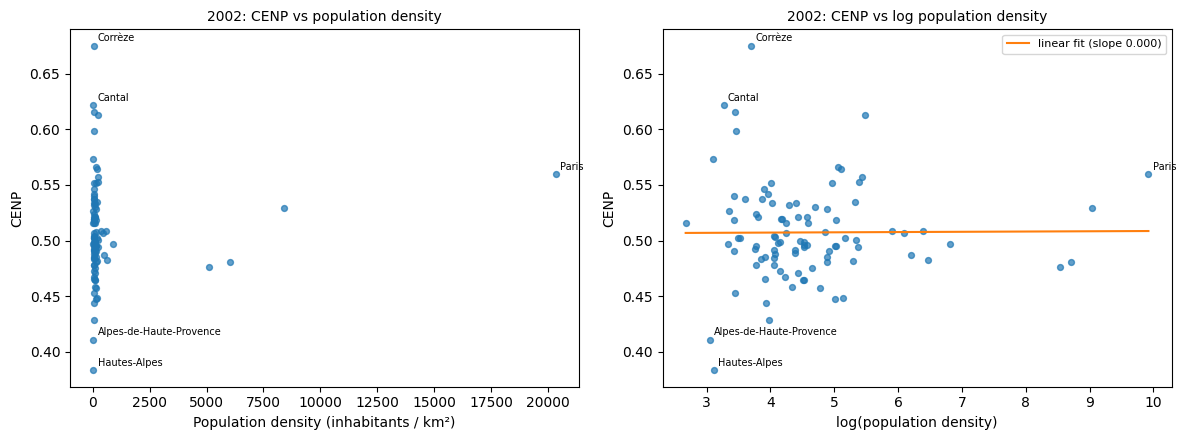

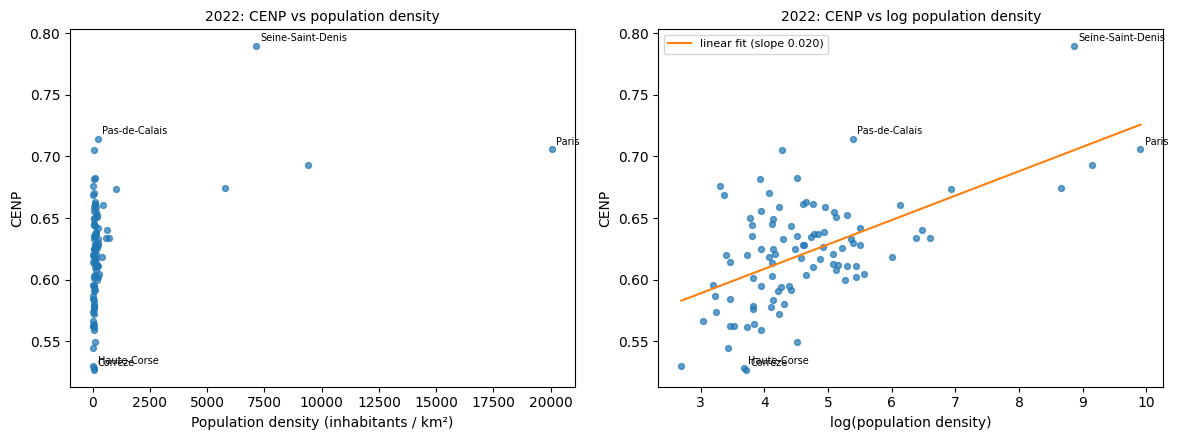

In [4]:
def density_scatters(df, year, y="CENP", ylabel="CENP"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    department_scatter(df, "density", y, axes[0], f"{year}: {ylabel} vs population density",
                       "Population density (inhabitants / km²)", ylabel, trend=False)
    department_scatter(df, "log_density", y, axes[1], f"{year}: {ylabel} vs log population density",
                       "log(population density)", ylabel)
    show_plot(fig)


for year in YEARS:
    density_scatters(main[main["year"] == year], year)

In [5]:
pd.DataFrame({year: association_stats(main[main["year"] == year], "CENP") for year in YEARS})

,2002,2022
n,96.000000,9.600000e+01
pearson_r,0.006686,5.724848e-01
pearson_p,0.948455,1.101295e-09
spearman_rho,-0.033207,4.569045e-01
spearman_p,0.748070,2.878042e-06
ols_coef,0.000235,1.980751e-02
ols_se,0.003632,2.925978e-03
ols_se_HC1,0.003759,3.335698e-03
ols_p,0.948455,1.101295e-09
ols_p_HC1,0.950185,4.820769e-08


In [6]:
# Full OLS output (descriptive: CENP ~ log_density)
for year in YEARS:
    print(f"===== {year} =====")
    print(smf.ols("CENP ~ log_density", data=main[main["year"] == year]).fit().summary())

===== 2002 =====
                            OLS Regression Results                            
Dep. Variable:                   CENP   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                  0.004202
Date:                Wed, 23 Sep 2026   Prob (F-statistic):              0.948
Time:                        12:09:20   Log-Likelihood:                 165.49
No. Observations:                  96   AIC:                            -327.0
Df Residuals:                      94   BIC:                            -321.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.5062      0.017

## 3. Changes between 2002 and 2022

Matched wide dataset, one row per metropolitan département:

* `delta_CENP = CENP_2022 − CENP_2002` — change in the observed concentration of the vote, not a coordination
  *gain* (16 vs 12 candidates, which CENP normalises for);
* `delta_log_density = log_density_2022 − log_density_2002` — same surface in both years, so ≈ population growth rate.

In [7]:
wide[["CENP_2002", "CENP_2022", "delta_CENP", "log_density_2002", "log_density_2022", "delta_log_density"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CENP_2002,96.0,0.507290,0.043391,0.383258,0.484082,0.500046,0.528644,0.675161
CENP_2022,96.0,0.621994,0.043344,0.526279,0.594651,0.622931,0.646132,0.789987
delta_CENP,96.0,0.114704,0.062637,-0.148882,0.091922,0.125671,0.146771,0.309395
log_density_2002,96.0,4.586577,1.232058,2.673311,3.889847,4.364239,5.012241,9.921107
log_density_2022,96.0,4.666628,1.252734,2.695061,3.909360,4.423900,5.125077,9.906190
delta_log_density,96.0,0.080052,0.089571,-0.122043,0.019921,0.070187,0.137542,0.278663


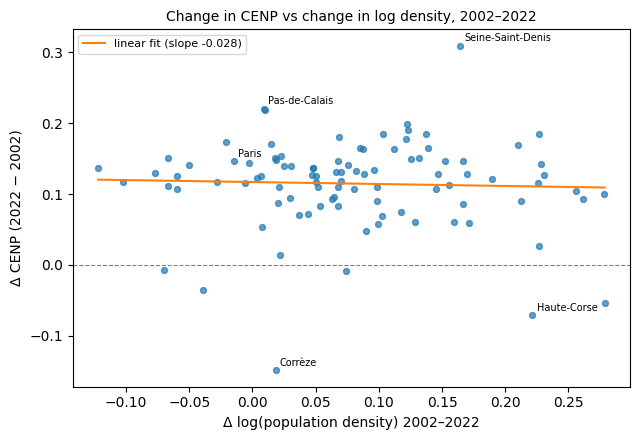

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
department_scatter(wide, "delta_log_density", "delta_CENP", ax, "Change in CENP vs change in log density, 2002–2022",
                   "Δ log(population density) 2002–2022", "Δ CENP (2022 − 2002)")
ax.axhline(0, color="grey", lw=0.8, ls="--")
show_plot(fig)

In [9]:
pearson = stats.pearsonr(wide["delta_CENP"], wide["delta_log_density"])
spearman = stats.spearmanr(wide["delta_CENP"], wide["delta_log_density"])
ols_delta = smf.ols("delta_CENP ~ delta_log_density", data=wide).fit()
robust_delta = ols_delta.get_robustcov_results(cov_type="HC1")

pd.Series({
    "n": int(ols_delta.nobs),
    "pearson_r": pearson.statistic, "pearson_p": pearson.pvalue,
    "spearman_rho": spearman.statistic, "spearman_p": spearman.pvalue,
    "ols_coef_delta_log_density": ols_delta.params["delta_log_density"],
    "ols_se": ols_delta.bse["delta_log_density"], "ols_p": ols_delta.pvalues["delta_log_density"],
    "ols_se_HC1": robust_delta.bse[1], "ols_p_HC1": robust_delta.pvalues[1], "ols_R2": ols_delta.rsquared,
}, name="delta_CENP ~ delta_log_density").to_frame()

,delta_CENP ~ delta_log_density
n,96.000000
pearson_r,-0.039650
pearson_p,0.701312
spearman_rho,-0.041129
spearman_p,0.690729
ols_coef_delta_log_density,-0.027727
ols_se,0.072071
ols_p,0.701312
ols_se_HC1,0.081289
ols_p_HC1,0.733791


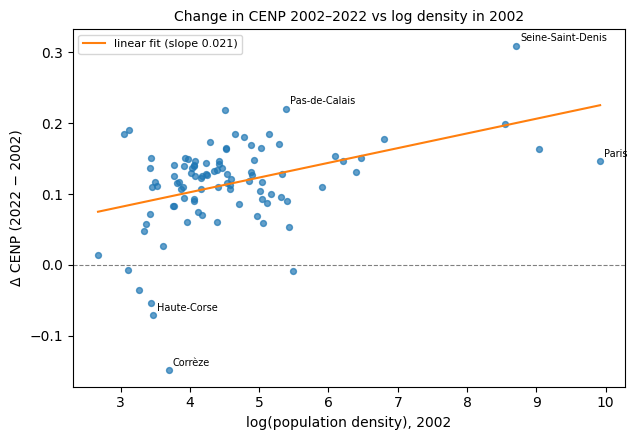

In [10]:
# Is the 2002 level of density associated with the change in coordination?
fig, ax = plt.subplots(figsize=(6.5, 4.5))
department_scatter(wide, "log_density_2002", "delta_CENP", ax, "Change in CENP 2002–2022 vs log density in 2002",
                   "log(population density), 2002", "Δ CENP (2022 − 2002)")
ax.axhline(0, color="grey", lw=0.8, ls="--")
show_plot(fig)

## 4. Secondary cliff measures

* `cliff_magnitude`: size of the largest drop between consecutive ranked vote shares;
* `cliff_ratio`: how much that drop stands out from the other gaps (0.5–1).

`cliff_location` is ordinal, so it is only described by its distribution across density quartiles, with a
Spearman rank correlation as a summary — no linear regression.

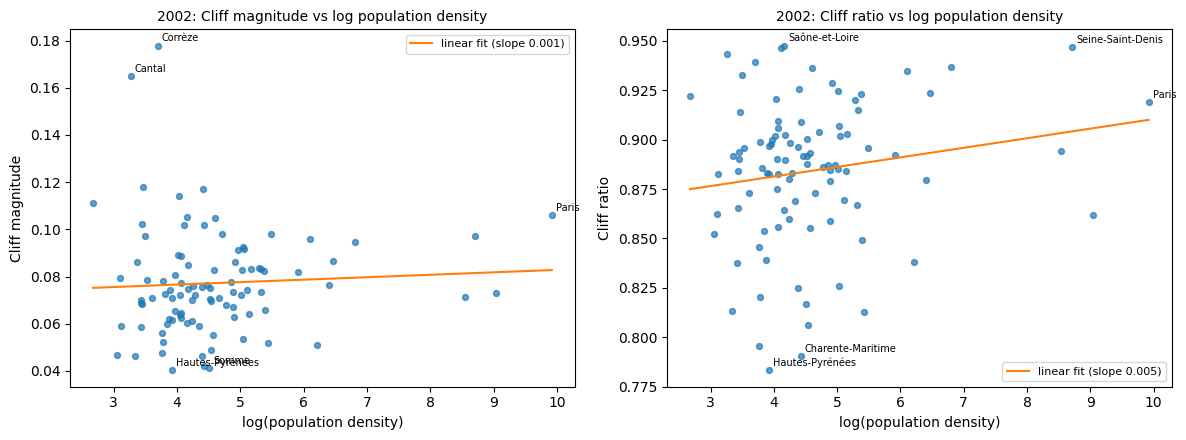

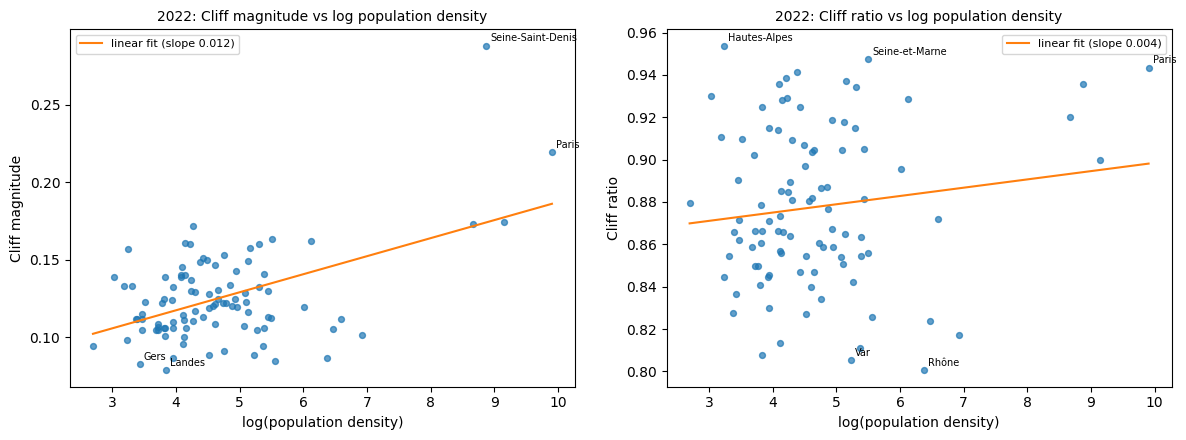

2002                                      2022                            
                   CENP cliff_magnitude cliff_ratio          CENP cliff_magnitude cliff_ratio
n             96.000000       96.000000   96.000000  9.600000e+01    9.600000e+01   96.000000
pearson_r      0.006686        0.056996    0.164001  5.724848e-01    4.953326e-01    0.131128
pearson_p      0.948455        0.581235    0.110343  1.101295e-09    2.885914e-07    0.202853
spearman_rho  -0.033207        0.139799    0.144235  4.569045e-01    2.140125e-01    0.059075
spearman_p     0.748070        0.174310    0.160904  2.878042e-06    3.628306e-02    0.567504
ols_coef       0.000235        0.001039    0.004844  1.980751e-02    1.163883e-02    0.003914
ols_se         0.003632        0.001876    0.003005  2.925978e-03    2.105329e-03    0.003052
ols_se_HC1     0.003759        0.001810    0.002792  3.335698e-03    3.826756e-03    0.003250
ols_p          0.948455        0.581235    0.110343  1.101295e-09    2.885914e-07    0.202853
ols_p_HC1      0.950185        0.567477    0.086002  4.820769e-08    3.051271e-03    0.231435
ols_R2         0.000045        0.003249    0.026896  3.277389e-01    2.453544e-01    0.017195

In [11]:
SECONDARY = {"cliff_magnitude": "Cliff magnitude", "cliff_ratio": "Cliff ratio"}

for year in YEARS:
    sub = main[main["year"] == year]
    fig, axes = plt.subplots(1, len(SECONDARY), figsize=(12, 4.5))
    for ax, (var, label) in zip(axes, SECONDARY.items()):
        department_scatter(sub, "log_density", var, ax, f"{year}: {label} vs log population density",
                           "log(population density)", label)
    show_plot(fig)

pd.concat({year: pd.DataFrame({var: association_stats(main[main["year"] == year], var) for var in ["CENP", *SECONDARY]})
           for year in YEARS}, axis=1)

In [12]:
# cliff_location: distribution (share of départements) by density quartile, within each year
for year in YEARS:
    sub = main[main["year"] == year]
    print(f"\n{year} — cliff_location by density quartile (row shares; n in last column)")
    table = pd.crosstab(sub["density_quartile"], sub["cliff_location"], normalize="index").round(2)
    table["n"] = sub.groupby("density_quartile").size()
    display(table)
    rho = stats.spearmanr(sub["cliff_location"], sub["density"])
    print(f"Spearman rho(cliff_location, density) = {rho.statistic:.3f} (p = {rho.pvalue:.3f})")


2002 — cliff_location by density quartile (row shares; n in last column)


cliff_location,1,2,3,4,n
density_quartile,,,,,
Q1 (least dense),0.33,0.21,0.46,0.00,24
Q2,0.04,0.17,0.79,0.00,24
Q3,0.25,0.21,0.50,0.04,24
Q4 (most dense),0.08,0.29,0.62,0.00,24


Spearman rho(cliff_location, density) = 0.118 (p = 0.251)

2022 — cliff_location by density quartile (row shares; n in last column)


cliff_location,1,2,3,n
density_quartile,,,,
Q1 (least dense),0.17,0.17,0.67,24
Q2,0.12,0.12,0.75,24
Q3,0.21,0.00,0.79,24
Q4 (most dense),0.12,0.29,0.58,24


Spearman rho(cliff_location, density) = -0.055 (p = 0.591)
